In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv("all_space_mission_launches.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
df.head()

,Unnamed: 0,Organisation,Location,Datetime,Details,Rocket_Status,Price,Mission_Status
0,0,VKS RF,"Site 43/4, Plesetsk Cosmodrome, Russia","Fri Feb 09, 2024 07:03 UTC",Soyuz 2.1v | Cosmos 2575,Active,NaN,Success
1,1,SpaceX,"SLC-40, Cape Canaveral SFS, Florida, USA","Thu Feb 08, 2024 06:33 UTC",Falcon 9 Block 5 | PACE,Active,67.0,Success
2,2,CASC,"Bo Run Jiu Zhou Barge (Area 2), China Coastal ...","Sat Feb 03, 2024 03:06 UTC",Jielong-3 | 9 satellites,Active,NaN,Success
3,3,CASC,"LC-3, Xichang Satellite Launch Center, China","Fri Feb 02, 2024 23:37 UTC",Long March 2C | Geely Constellation Group 02,Active,30.8,Success
4,4,Rocket Lab,"Rocket Lab LC-1B, Māhia Peninsula, New Zealand","Wed Jan 31, 2024 06:34 UTC",Electron/Curie | Four Of A Kind,Active,7.5,Success


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6711 entries, 0 to 6710
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      6711 non-null   int64  
 1   Organisation    6711 non-null   object 
 2   Location        6711 non-null   object 
 3   Datetime        6711 non-null   object 
 4   Details         6711 non-null   object 
 5   Rocket_Status   6711 non-null   object 
 6   Price           2637 non-null   float64
 7   Mission_Status  6711 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 419.6+ KB


In [6]:
print(df.isnull().sum())    #Missing Values

Unnamed: 0           0
Organisation         0
Location             0
Datetime             0
Details              0
Rocket_Status        0
Price             4074
Mission_Status       0
dtype: int64


In [7]:
# Fill numerical columns with mean

numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col].fillna(df[col].mean(), inplace=True)

# Fill categorical columns with mode

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values handled successfully.")

Missing values handled successfully.


In [8]:
print("Duplicate Rows =", df.duplicated().sum())     #check duplicate rows

Duplicate Rows = 0


In [9]:
print(df.select_dtypes(include=np.number).columns)      #Display Numerical Columns

Index(['Unnamed: 0', 'Price'], dtype='object')


In [10]:
column = "Price"              #Detect Outliers

Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df[column] < lower) | (df[column] > upper)]

print(outliers)

      Unnamed: 0 Organisation  \
3              3         CASC   
4              4   Rocket Lab   
17            17          MHI   
18            18   OrienSpace   
19            19       ExPace   
...          ...          ...   
5132         632    RVSN USSR   
5134         634    RVSN USSR   
5177         677    RVSN USSR   
5194         694    RVSN USSR   
5238         738    RVSN USSR   

                                              Location  \
3         LC-3, Xichang Satellite Launch Center, China   
4       Rocket Lab LC-1B, Māhia Peninsula, New Zealand   
17              LA-Y1, Tanegashima Space Center, Japan   
18             Haiyang Spaceport, China Coastal Waters   
19    Site 95A, Jiuquan Satellite Launch Center, China   
...                                                ...   
5132        Site 31/6, Baikonur Cosmodrome, Kazakhstan   
5134        Site 31/6, Baikonur Cosmodrome, Kazakhstan   
5177            Site 43/3, Plesetsk Cosmodrome, Russia   
5194            Site 43

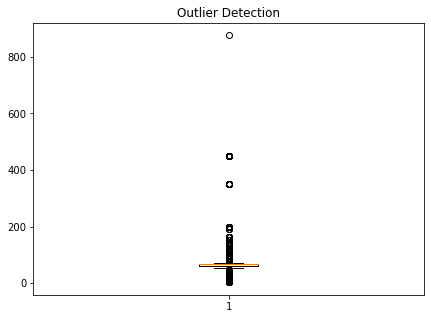

In [11]:
plt.figure(figsize=(7,5))         #Box Plot

plt.boxplot(df[column].dropna())

plt.title("Outlier Detection")

plt.show()

In [12]:
scaler = MinMaxScaler()         #Normalize Numerical Data

df[[column]] = scaler.fit_transform(df[[column]])

df[[column]].head()

,Price
0,0.076316
1,0.073841
2,0.076316
3,0.032398
4,0.005724


In [13]:
print(df.select_dtypes(include='object').columns)        #Display Categorical Columns

Index(['Organisation', 'Location', 'Datetime', 'Details', 'Rocket_Status',
       'Mission_Status'],
      dtype='object')


In [15]:
encoder = LabelEncoder()                    #Label Encoding

df["Company"] = encoder.fit_transform(df["Organisation"])

df.head()

,Unnamed: 0,Organisation,Location,Datetime,Details,Rocket_Status,Price,Mission_Status,Company
0,0,VKS RF,"Site 43/4, Plesetsk Cosmodrome, Russia","Fri Feb 09, 2024 07:03 UTC",Soyuz 2.1v | Cosmos 2575,Active,0.076316,Success,62
1,1,SpaceX,"SLC-40, Cape Canaveral SFS, Florida, USA","Thu Feb 08, 2024 06:33 UTC",Falcon 9 Block 5 | PACE,Active,0.073841,Success,56
2,2,CASC,"Bo Run Jiu Zhou Barge (Area 2), China Coastal ...","Sat Feb 03, 2024 03:06 UTC",Jielong-3 | 9 satellites,Active,0.076316,Success,11
3,3,CASC,"LC-3, Xichang Satellite Launch Center, China","Fri Feb 02, 2024 23:37 UTC",Long March 2C | Geely Constellation Group 02,Active,0.032398,Success,11
4,4,Rocket Lab,"Rocket Lab LC-1B, Māhia Peninsula, New Zealand","Wed Jan 31, 2024 06:34 UTC",Electron/Curie | Four Of A Kind,Active,0.005724,Success,49


In [21]:
encoded = pd.get_dummies(df["Rocket_Status"])      #One-Hot Encoding

encoded.head()

,Active,Retired
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


In [22]:
df.head()          #Final Dataset

,Unnamed: 0,Organisation,Location,Datetime,Details,Rocket_Status,Price,Mission_Status,Company
0,0,VKS RF,"Site 43/4, Plesetsk Cosmodrome, Russia","Fri Feb 09, 2024 07:03 UTC",Soyuz 2.1v | Cosmos 2575,Active,0.076316,Success,62
1,1,SpaceX,"SLC-40, Cape Canaveral SFS, Florida, USA","Thu Feb 08, 2024 06:33 UTC",Falcon 9 Block 5 | PACE,Active,0.073841,Success,56
2,2,CASC,"Bo Run Jiu Zhou Barge (Area 2), China Coastal ...","Sat Feb 03, 2024 03:06 UTC",Jielong-3 | 9 satellites,Active,0.076316,Success,11
3,3,CASC,"LC-3, Xichang Satellite Launch Center, China","Fri Feb 02, 2024 23:37 UTC",Long March 2C | Geely Constellation Group 02,Active,0.032398,Success,11
4,4,Rocket Lab,"Rocket Lab LC-1B, Māhia Peninsula, New Zealand","Wed Jan 31, 2024 06:34 UTC",Electron/Curie | Four Of A Kind,Active,0.005724,Success,49
